In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("iris.csv")

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = df[["sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width" ]]

In [ ]:
y = df["species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = SVC(kernel="rbf", C=1, gamma="scale")

In [ ]:
model.fit(X_train,y_train)

SVC(C=1)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9666666666666667


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


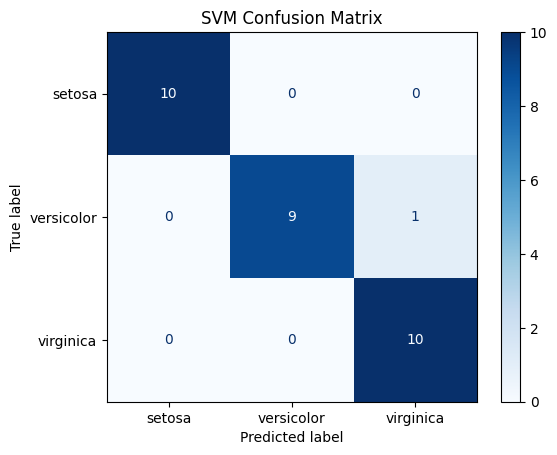

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
X_visual = df[[
    "petal_length",
    "petal_width"
]]

In [ ]:
y_visual = y


In [ ]:
class_names = sorted(y_visual.unique())

class_map = {
    name: i for i, name in enumerate(class_names)
}

y_numeric = y_visual.map(class_map)

In [ ]:
scaler_visual = StandardScaler()

X_visual_scaled = scaler_visual.fit_transform(X_visual)



In [ ]:
svm_visual = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_visual.fit(X_visual_scaled, y_numeric)

SVC(C=1)

In [ ]:
x_min = X_visual_scaled[:, 0].min() - 1
x_max = X_visual_scaled[:, 0].max() + 1

y_min = X_visual_scaled[:, 1].min() - 1
y_max = X_visual_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

In [ ]:
Z = svm_visual.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


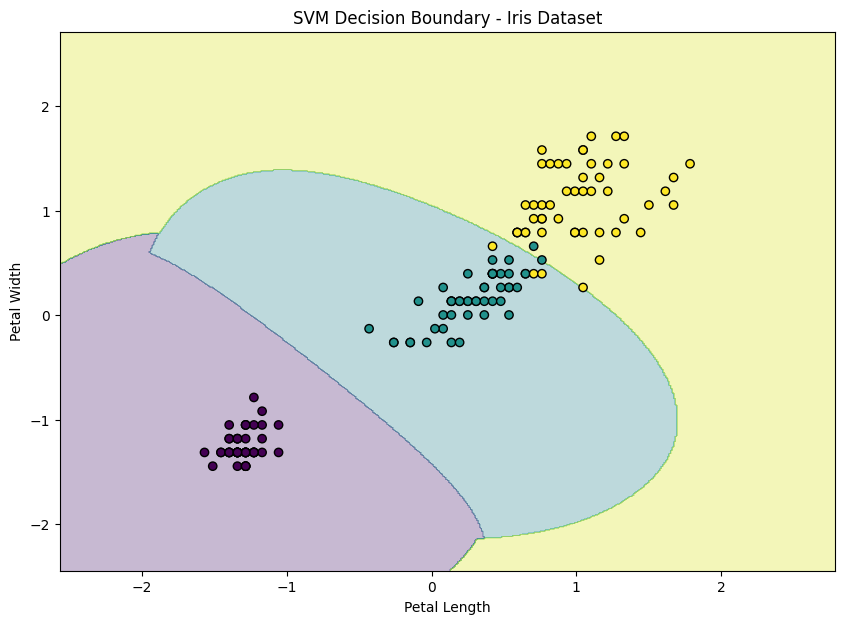

In [ ]:
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X_visual_scaled[:, 0],
    X_visual_scaled[:, 1],
    c=y_numeric,
    edgecolors="black"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.title("SVM Decision Boundary - Iris Dataset")

plt.show()

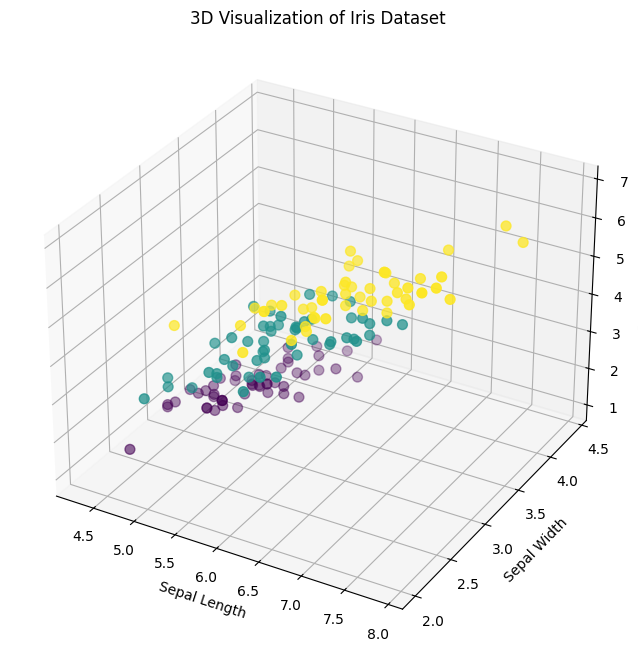

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X_3d = df[[
    "sepal_length",
    "sepal_width",
    "petal_length"
]]

y_3d = df["species"]


class_names = sorted(y_3d.unique())

class_map = {
    name: i for i, name in enumerate(class_names)
}

y_numeric = y_3d.map(class_map)


fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")


scatter = ax.scatter(
    X_3d["sepal_length"],
    X_3d["sepal_width"],
    X_3d["petal_length"],
    c=y_numeric,
    s=50
)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

ax.set_title("3D Visualization of Iris Dataset")

plt.show()

Weights: [ 0.48828962 -0.45052667  1.28928618]
Bias: 0.38473775607857985


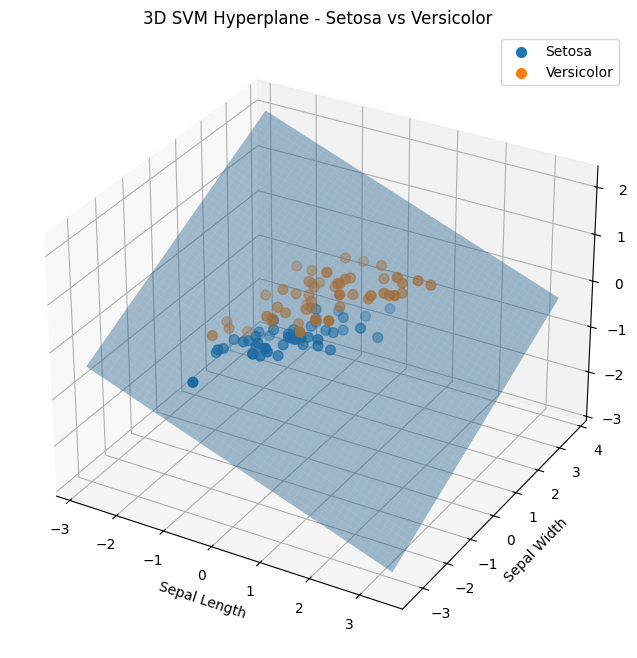

In [ ]:
# ==========================================
# SVM 3D HYPERPLANE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# 1. Select only Setosa and Versicolor
# ------------------------------------------

data = df[df["species"].isin(["setosa", "versicolor"])].copy()

# Select the same 3 features used in your 3D graph
X = data[[
    "sepal_length",
    "sepal_width",
    "petal_length"
]]

y = data["species"]


# ------------------------------------------
# 2. Convert classes into numbers
# ------------------------------------------

y = y.map({
    "setosa": 0,
    "versicolor": 1
})


# ------------------------------------------
# 3. Standardize the features
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ------------------------------------------
# 4. Create Linear SVM
# ------------------------------------------

svm = SVC(
    kernel="linear",
    C=1
)

svm.fit(X_scaled, y)


# ------------------------------------------
# 5. Get hyperplane parameters
# ------------------------------------------

w = svm.coef_[0]
b = svm.intercept_[0]

print("Weights:", w)
print("Bias:", b)


# ------------------------------------------
# 6. Create X and Y grid
# ------------------------------------------

x_min = X_scaled[:, 0].min() - 1
x_max = X_scaled[:, 0].max() + 1

y_min = X_scaled[:, 1].min() - 1
y_max = X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 50),
    np.linspace(y_min, y_max, 50)
)


# ------------------------------------------
# 7. Calculate Z for hyperplane
# ------------------------------------------

# Equation:
#
# w1*x + w2*y + w3*z + b = 0
#
# Therefore:
#
# z = -(w1*x + w2*y + b) / w3

zz = -(w[0] * xx + w[1] * yy + b) / w[2]


# ------------------------------------------
# 8. Create 3D graph
# ------------------------------------------

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)


# ------------------------------------------
# 9. Plot Setosa
# ------------------------------------------

ax.scatter(
    X_scaled[y == 0, 0],
    X_scaled[y == 0, 1],
    X_scaled[y == 0, 2],
    label="Setosa",
    s=50
)


# ------------------------------------------
# 10. Plot Versicolor
# ------------------------------------------

ax.scatter(
    X_scaled[y == 1, 0],
    X_scaled[y == 1, 1],
    X_scaled[y == 1, 2],
    label="Versicolor",
    s=50
)


# ------------------------------------------
# 11. Plot Hyperplane
# ------------------------------------------

ax.plot_surface(
    xx,
    yy,
    zz,
    alpha=0.4
)


# ------------------------------------------
# 12. Labels
# ------------------------------------------

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

ax.set_title(
    "3D SVM Hyperplane - Setosa vs Versicolor"
)

ax.legend()

plt.show()

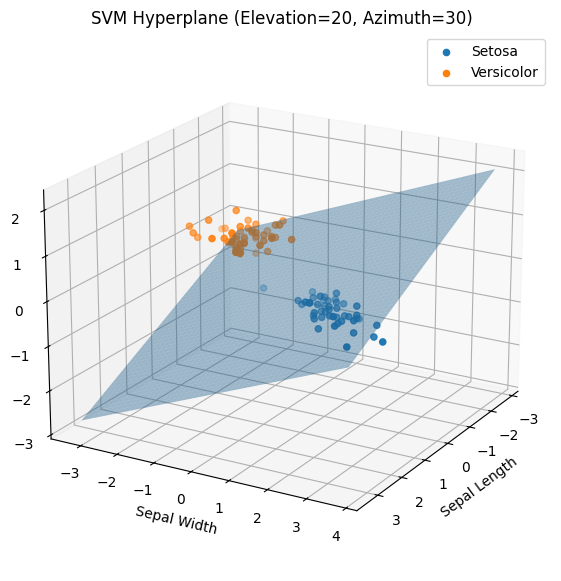

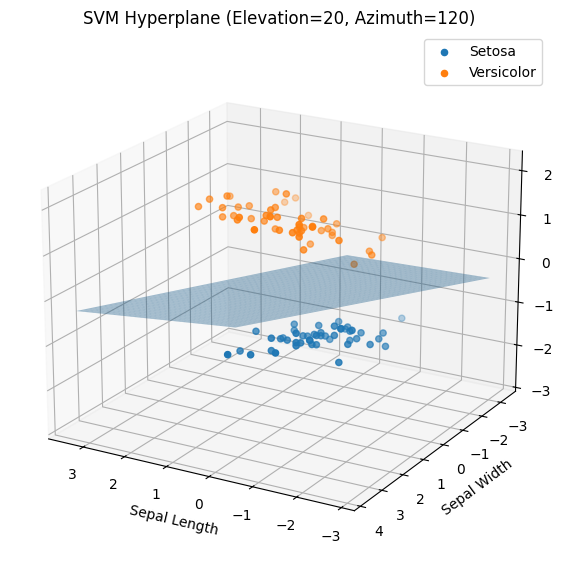

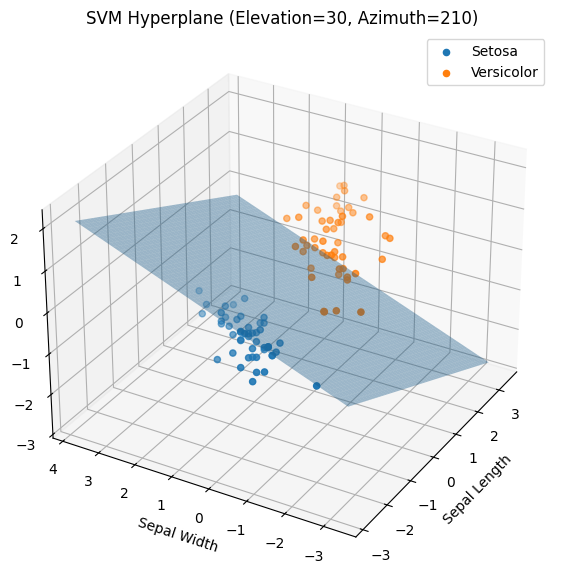

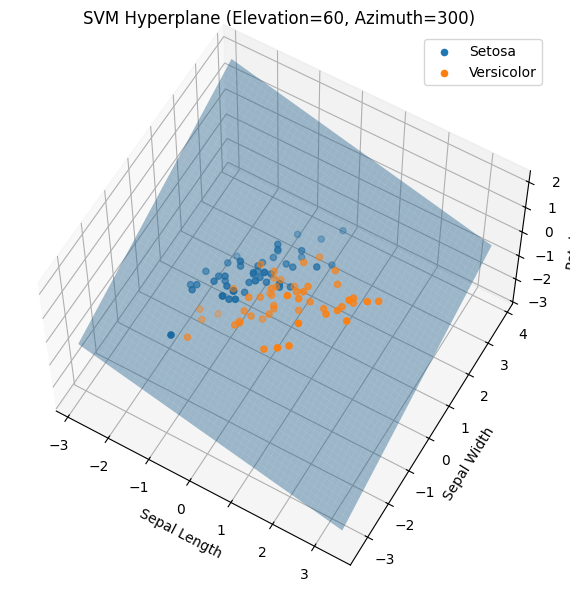

In [ ]:
# Different viewing angles

angles = [
    (20, 30),
    (20, 120),
    (30, 210),
    (60, 300)
]

for elevation, azimuth in angles:

    fig = plt.figure(figsize=(9, 7))

    ax = fig.add_subplot(111, projection="3d")

    # Setosa
    ax.scatter(
        X_scaled[y == 0, 0],
        X_scaled[y == 0, 1],
        X_scaled[y == 0, 2],
        label="Setosa"
    )

    # Versicolor
    ax.scatter(
        X_scaled[y == 1, 0],
        X_scaled[y == 1, 1],
        X_scaled[y == 1, 2],
        label="Versicolor"
    )

    # Hyperplane
    ax.plot_surface(
        xx,
        yy,
        zz,
        alpha=0.4
    )

    ax.set_xlabel("Sepal Length")
    ax.set_ylabel("Sepal Width")
    ax.set_zlabel("Petal Length")

    ax.set_title(
        f"SVM Hyperplane (Elevation={elevation}, Azimuth={azimuth})"
    )

    ax.view_init(
        elev=elevation,
        azim=azimuth
    )

    ax.legend()

    plt.show()